# Credit Balance Analysis

## What This Notebook Is About

This notebook investigates how credit card **balance** (amount owed) varies across demographic groups. We systematically compare three binary characteristics:

- **Married** (Yes / No)
- **Student** (Yes / No)
- **Own house** (Yes / No)

For each characteristic we ask the same question: **"Is the average balance significantly different between the two groups?"**

---

### Why This Analysis Matters

Credit balance is a proxy for financial behaviour. Lenders, policy-makers, and marketers need to know whether certain groups systematically carry higher balances — this informs risk models, product design, and customer segmentation.

---

### The Statistical Framework

For each grouping variable, we run a **Welch two-sample t-test**:

- **H₀**: The two groups have the same mean balance (e.g. married = not married)
- **H₁**: The groups have different mean balances

We use **Welch's version** (`equal_var=False`) rather than Student's t-test because:
- The two groups may have different sample sizes
- The variance (spread) may differ between groups (e.g. students are likely more variable)
- Welch's test is robust to both issues; Student's is not

---

### What You Will Learn

| Concept | Where |
|---|---|
| Reusable analysis functions: `def analyse_balance_by_group(...)` | Section 4 |
| Side-by-side subplots: `plt.subplots(1, 2)` | Section 4 |
| Overlapping density histograms with `density=True` | Section 4 |
| Seaborn `pairplot` for joint distributions | Section 4 |
| Welch t-test: `stats.ttest_ind(equal_var=False)` | Section 4 |
| 95% CI for the difference: `stats.t.interval()` | Section 4 |
| Compact results table with a loop across variables | Section 8 |

---

### Libraries Used
- **`scipy.stats`** — `ttest_ind`, `t.interval`
- **`pandas`** — `groupby`, `describe`, `rename`
- **`seaborn`** — `boxplot`, `pairplot`
- **`matplotlib`** — subplot layout, histogram overlay

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['font.size']   = 12
plt.rcParams['font.family'] = 'sans-serif'

## 2. Load & Inspect Data

In [2]:
credit = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/credit.csv")


# Rename 'own' to 'own_house' for clarity
credit = credit.rename(columns={'own': 'own_house'})

print(f"Shape: {credit.shape}")
credit.info()

Shape: (400, 11)
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   income     400 non-null    float64
 1   limit      400 non-null    int64  
 2   rating     400 non-null    int64  
 3   cards      400 non-null    int64  
 4   age        400 non-null    int64  
 5   education  400 non-null    int64  
 6   own_house  400 non-null    str    
 7   student    400 non-null    str    
 8   married    400 non-null    str    
 9   region     400 non-null    str    
 10  balance    400 non-null    int64  
dtypes: float64(1), int64(6), str(4)
memory usage: 34.5 KB


In [3]:
credit.head()

,income,limit,rating,cards,age,education,own_house,student,married,region,balance
0,14.891,3606,283,2,34,11,No,No,Yes,South,333
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.593,7075,514,4,71,11,No,No,No,West,580
3,148.924,9504,681,3,36,11,Yes,No,No,West,964
4,55.882,4897,357,2,68,16,No,No,Yes,South,331


## 3. Summary Statistics

Overall balance distribution, then broken down by each grouping variable.

In [4]:
print("--- Overall balance ---")
display(credit['balance'].describe().round(2).to_frame().T)

print("\n--- Balance by married ---")
display(credit.groupby('married')['balance'].describe().round(2))

print("\n--- Balance by student ---")
display(credit.groupby('student')['balance'].describe().round(2))

print("\n--- Balance by own_house ---")
display(credit.groupby('own_house')['balance'].describe().round(2))

--- Overall balance ---


,count,mean,std,min,25%,50%,75%,max
balance,400.0,520.02,459.76,0.0,68.75,459.5,863.0,1999.0



--- Balance by married ---


,count,mean,std,min,25%,50%,75%,max
married,,,,,,,,
No,155.0,523.29,470.89,0.0,51.0,467.0,910.0,1687.0
Yes,245.0,517.94,453.54,0.0,81.0,454.0,844.0,1999.0



--- Balance by student ---


,count,mean,std,min,25%,50%,75%,max
student,,,,,,,,
No,360.0,480.37,439.41,0.0,13.25,424.0,807.5,1999.0
Yes,40.0,876.82,490.00,0.0,428.00,953.0,1256.0,1687.0



--- Balance by own_house ---


,count,mean,std,min,25%,50%,75%,max
own_house,,,,,,,,
No,193.0,509.80,462.12,0.0,5.0,463.0,815.0,1999.0
Yes,207.0,529.54,458.46,0.0,92.0,456.0,887.0,1809.0


## 4. Helper: Plot + T-Test

A reusable function that produces the boxplot, density histogram, pairplot, and Welch t-test for any binary grouping variable vs balance.

In [5]:
def analyse_balance_by_group(df, group_col, group_label):
    """
    A reusable function that runs the full analysis pipeline for one grouping variable.

    For a binary categorical variable (e.g. 'married'):
      1. Side-by-side boxplot + density histogram (see the distribution shape and spread)
      2. Pairplot (joint and marginal distributions)
      3. Welch two-sample t-test with detailed output (R-style summary)

    Parameters
    ----------
    df          : pd.DataFrame  — the full credit dataset
    group_col   : str           — column name of the binary grouping variable
    group_label : str           — human-readable label for titles and output
    """
    # Extract the two category values (e.g. ['Yes', 'No'])
    # .unique() returns all distinct values in the column
    groups = df[group_col].dropna().unique()

    # ==========================================================================
    # PLOT 1: Boxplot + Density Histogram (side by side)
    # ==========================================================================
    # plt.subplots(1, 2): creates ONE row of TWO subplots
    # Returns (fig, axes): fig = the whole figure, (ax1, ax2) = individual panels
    # figsize=(11, 4): 11 inches wide, 4 inches tall
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(f'Balance vs. {group_label}', fontsize=14, fontweight='bold')

    # --- Panel 1: Boxplot ---
    # Shows median, IQR (box), whiskers (1.5×IQR), and outlier dots
    # x='balance': horizontal boxplots (easier to compare distributions)
    # y=group_col: one boxplot per category
    sns.boxplot(data=df, x='balance', y=group_col, ax=ax1)
    ax1.set_title('Boxplot')
    ax1.set_xlabel('Balance')
    ax1.set_ylabel('')

    # --- Panel 2: Overlapping density histograms ---
    # We loop over each group and draw its histogram on the SAME axes (ax2)
    # density=True normalises: y-axis = probability density, not raw counts
    # This allows fair comparison even when group sizes differ
    # alpha=0.3: semi-transparent so both histograms are visible where they overlap
    for g in groups:
        subset = df[df[group_col] == g]['balance'].dropna()
        ax2.hist(subset, alpha=0.3, density=True, label=g, bins=20)
    ax2.set_xlabel('Balance')
    ax2.set_ylabel('Density')
    ax2.set_title('Density Histogram')
    ax2.legend()

    plt.tight_layout()   # prevent subplot titles/labels from overlapping
    plt.show()

    # ==========================================================================
    # PLOT 2: Pairplot
    # ==========================================================================
    # sns.pairplot creates a matrix of scatter + density plots for selected columns.
    # With hue=group_col, each category gets its own colour.
    # For two variables (group + balance), the matrix is 2×2:
    #   Top-left: group distribution (diagonal)
    #   Top-right / Bottom-left: scatter (balance vs group encoding)
    #   Bottom-right: balance distribution
    # diag_kind='hist': use histograms on the diagonal (instead of KDE)
    g = sns.pairplot(df[[group_col, 'balance']], hue=group_col, diag_kind='hist')
    g.fig.suptitle(f'Pairplot: Balance vs. {group_label}', y=1.02)
    plt.show()

    # ==========================================================================
    # WELCH TWO-SAMPLE T-TEST
    # ==========================================================================
    # Tests: "Do these two groups have the same mean balance?"
    # H₀: μ_group0 = μ_group1
    # H₁: μ_group0 ≠ μ_group1   (two-sided test)
    #
    # We use Welch's t-test (equal_var=False) which is appropriate because:
    #   - Sample sizes may differ
    #   - Variance (spread) may differ between groups
    # Student's t-test (equal_var=True) assumes σ₁ = σ₂ — a strong assumption
    # that often doesn't hold. Welch's is the safer default.

    x = df[df[group_col] == groups[0]]['balance'].dropna()   # first group's balances
    y = df[df[group_col] == groups[1]]['balance'].dropna()   # second group's balances

    t_stat, p_value = stats.ttest_ind(x, y, equal_var=False)

    # --- Compute 95% CI for the DIFFERENCE in means ---
    # This tells us: "The true difference in population means is likely between X and Y"
    # If CI excludes 0 → the groups are significantly different (confirms the p-value)
    diff = x.mean() - y.mean()                               # point estimate of the difference
    se   = np.sqrt(x.var(ddof=1)/len(x) + y.var(ddof=1)/len(y))  # pooled SE for the difference
    df_w = (x.var()/len(x) + y.var()/len(y))**2 / (
           (x.var()/len(x))**2/(len(x)-1) + (y.var()/len(y))**2/(len(y)-1))  # Welch df
    ci   = stats.t.interval(0.95, df=df_w, loc=diff, scale=se)

    sig  = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    print(f"--- Welch T-Test: balance by {group_label} ---")
    print(f"  n         : {len(x)} ({groups[0]})  vs  {len(y)} ({groups[1]})")
    print(f"  mean      : {x.mean():.2f}  vs  {y.mean():.2f}")
    print(f"  std       : {x.std(ddof=1):.2f}  vs  {y.std(ddof=1):.2f}")
    print(f"  diff      : {diff:.2f}  ({groups[0]} minus {groups[1]})")
    print(f"  95% CI    : [{ci[0]:.2f}, {ci[1]:.2f}]")   # does this exclude 0?
    print(f"  t         : {t_stat:.4f}")
    print(f"  df        : {df_w:.2f}")
    print(f"  p-value   : {p_value:.4f}  {sig}")
    print()

print("Helper function defined.")

Helper function defined.


## 5. Balance vs. Married

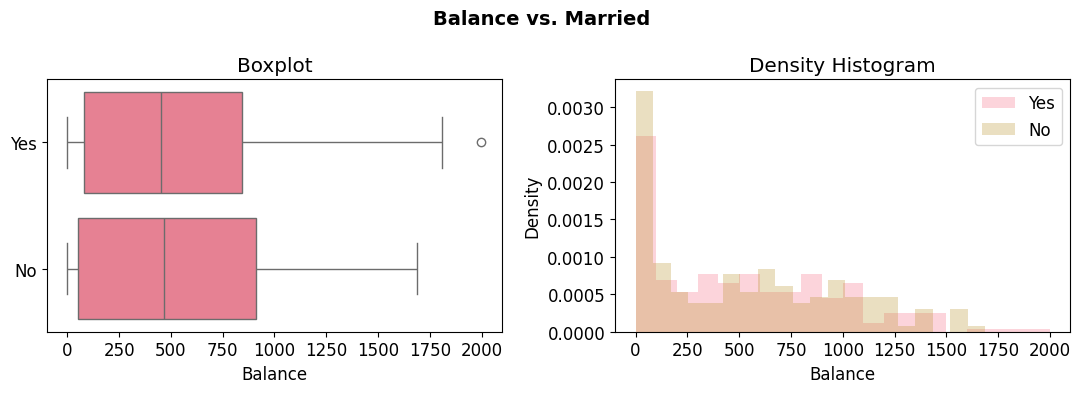

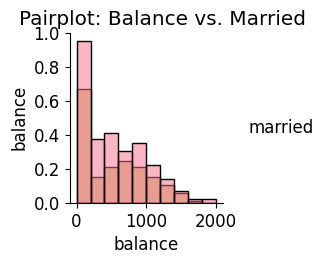

--- Welch T-Test: balance by Married ---
  n         : 245 (Yes)  vs  155 (No)
  mean      : 517.94  vs  523.29
  std       : 453.54  vs  470.89
  diff      : -5.35  (Yes minus No)
  95% CI    : [-99.09, 88.39]
  t         : -0.1122
  df        : 318.56
  p-value   : 0.9107  ns



In [6]:
analyse_balance_by_group(credit, 'married', 'Married')

## 6. Balance vs. Student

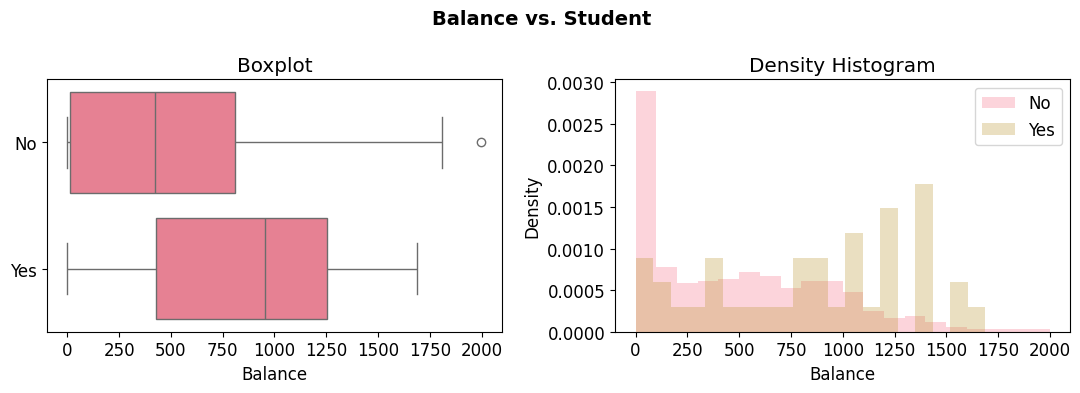

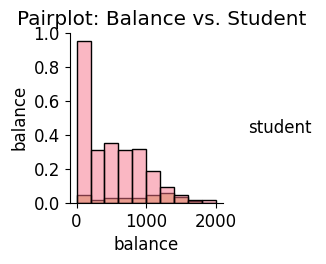

--- Welch T-Test: balance by Student ---
  n         : 360 (No)  vs  40 (Yes)
  mean      : 480.37  vs  876.83
  std       : 439.41  vs  490.00
  diff      : -396.46  (No minus Yes)
  95% CI    : [-559.20, -233.71]
  t         : -4.9028
  df        : 46.24
  p-value   : 0.0000  ***



In [7]:
analyse_balance_by_group(credit, 'student', 'Student')

## 7. Balance vs. Own House

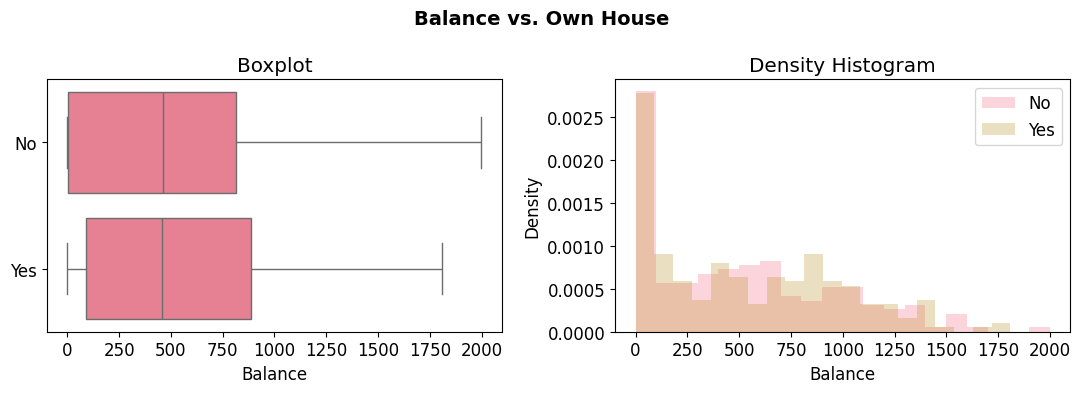

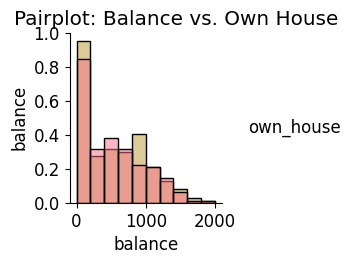

--- Welch T-Test: balance by Own House ---
  n         : 193 (No)  vs  207 (Yes)
  mean      : 509.80  vs  529.54
  std       : 462.12  vs  458.46
  diff      : -19.73  (No minus Yes)
  95% CI    : [-110.29, 70.83]
  t         : -0.4284
  df        : 395.58
  p-value   : 0.6686  ns



In [8]:
analyse_balance_by_group(credit, 'own_house', 'Own House')

## 8. Summary of T-Test Results

A quick side-by-side comparison of all three tests.

In [9]:
# =============================================================================
# SECTION 8: Summary of T-Test Results — all three variables in one table
# =============================================================================
# Instead of copying the t-test code three times, we use a LOOP over the three
# variables. Each iteration of the loop:
#   1. Splits the data into the two groups for that variable
#   2. Runs the Welch t-test
#   3. Appends a results dictionary to the 'results' list
#
# Finally, pd.DataFrame(results) converts the list of dicts into a clean table.
#
# KEY PATTERN: list of dicts → DataFrame
#   results = []
#   for ...:
#       results.append({'col1': val1, 'col2': val2, ...})
#   df = pd.DataFrame(results)
#
# This is a common pandas pattern when you're building a results table row by row.
# Each dictionary becomes one row; the keys become column names.
#
# .set_index('Variable'): use the Variable column as the row label (index)
# This produces a clean table where each row = one comparison

results = []

for col, label in [('married', 'Married'), ('student', 'Student'), ('own_house', 'Own House')]:
    groups = credit[col].dropna().unique()
    x = credit[credit[col] == groups[0]]['balance'].dropna()
    y = credit[credit[col] == groups[1]]['balance'].dropna()

    t_stat, p_value = stats.ttest_ind(x, y, equal_var=False)   # Welch t-test

    results.append({
        'Variable':             label,
        f'Mean ({groups[0]})':  round(x.mean(), 2),
        f'Mean ({groups[1]})':  round(y.mean(), 2),
        'Difference':           round(x.mean() - y.mean(), 2),  # group0 − group1
        't-stat':               round(t_stat, 4),
        'p-value':              round(p_value, 4),
        'Sig':                  '***' if p_value < 0.001
                                else '**' if p_value < 0.01
                                else '*'  if p_value < 0.05
                                else 'ns'
    })

display(pd.DataFrame(results).set_index('Variable'))

# HOW TO INTERPRET:
#   Student=Yes has a dramatically higher mean balance — and p<0.001 (***).
#   Married and Own House show much smaller differences — check their p-values.
#   This table lets you compare effect sizes (Difference) alongside significance.

,Mean (Yes),Mean (No),Difference,t-stat,p-value,Sig
Variable,,,,,,
Married,517.94,523.29,-5.35,-0.1122,0.9107,ns
Student,876.82,480.37,-396.46,-4.9028,0.0000,***
Own House,529.54,509.80,-19.73,-0.4284,0.6686,ns
